# NEOPAX Profile Closure

## What you will learn
Why profiles and sources close the loop between field optimization and performance.

## Codes used
NEOPAX in research mode; educational radial diffusion/source model by default.

## Run mode
This notebook uses RUN_MODE = "cached" by default. Allowed values are "tiny", "cached", and "research".

## Expected outputs
`10_profile_evolution.png` and `10_power_balance.png`.

## What this teaches

The object is profile closure: sources, transport, and radial profiles feeding back into design credibility.

## What this does not prove

It does not prove a live NEOPAX prediction or a complete discharge scenario.

## Literature anchor

A stellarator field is not a reactor scenario until sources, sinks, neoclassical terms, turbulent transport, and profile response close consistently. Nonlinear turbulence optimization papers increasingly finish with transport/profile checks because a geometry-only winner can lose after profile feedback.

Reading: Kim et al., https://arxiv.org/abs/2310.18842.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "sos2026").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project root: repository root detected")

Project root: repository root detected


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected. Keep RUN_MODE='cached' first; install requirements-colab.txt from the cloned repo if needed.")
else:
    print("Local runtime detected.")

Local runtime detected.


In [3]:
RUN_MODE = "cached"  # allowed: "tiny", "cached", "research"
print(f"RUN_MODE = {RUN_MODE}")

RUN_MODE = cached


In [4]:
import importlib
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False})

from sos2026.paths import PROJECT_ROOT, DATA_DIR, CACHE_DIR, FIGURE_DIR, MOVIE_DIR, ensure_directories
ensure_directories()
print("Figures:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Cached data:", CACHE_DIR.relative_to(PROJECT_ROOT))

Figures: assets/figures
Cached data: data/cached


## 1. Learning frame

This notebook is a deliberately small project: define one metric, produce one plot, expose one failure mode, and identify where a real code would enter.

In [5]:
from sos2026.transport_helpers import profile_closure
from sos2026.plotting import savefig, caption

## 2. Load or generate the teaching data

Cached mode uses small arrays so the conceptual workflow is always available.

In [6]:
d = profile_closure()
pd.DataFrame({"r": d["r"], "source": d["source"], "chi_base": d["chi_base"]}).head()

,r,source,chi_base
0,0.000000,1.000000,0.250000
1,0.010101,0.999490,0.250015
2,0.020202,0.997961,0.250061
3,0.030303,0.995419,0.250138
4,0.040404,0.991871,0.250245


## 3. Make the primary plot

Every plot has a one-sentence caption because students should know how to read it without guessing.

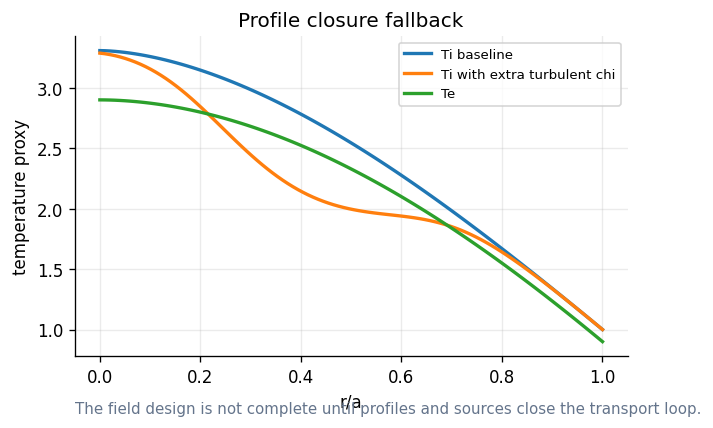

In [7]:
fig, ax = plt.subplots(figsize=(6.0, 3.7))
ax.plot(d["r"], d["Ti_base"], lw=2, label="Ti baseline")
ax.plot(d["r"], d["Ti_turbulent"], lw=2, label="Ti with extra turbulent chi")
ax.plot(d["r"], d["Te"], lw=2, label="Te")
ax.set_xlabel("r/a")
ax.set_ylabel("temperature proxy")
ax.set_title("Profile closure fallback")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
caption(ax, "The field design is not complete until profiles and sources close the transport loop.")
savefig(fig, "10_profile_evolution.png")
plt.show()

## 4. Probe the metric

A metric becomes useful for optimization only when we understand how it changes across design choices.

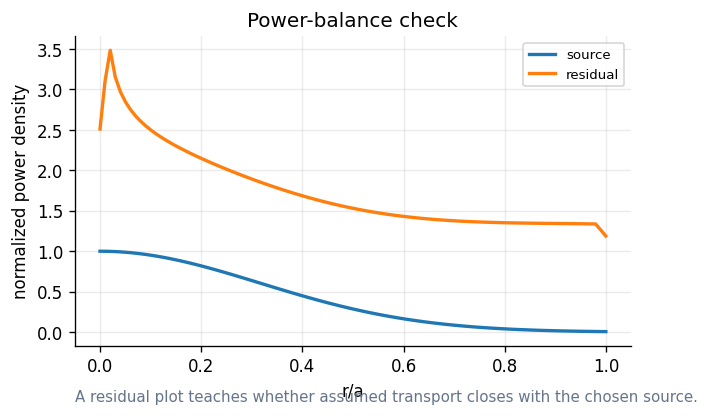

In [8]:
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(d["r"], d["source"], lw=2, label="source")
ax.plot(d["r"], d["flux_balance"], lw=2, label="residual")
ax.set_xlabel("r/a")
ax.set_ylabel("normalized power density")
ax.set_title("Power-balance check")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
caption(ax, "A residual plot teaches whether assumed transport closes with the chosen source.")
savefig(fig, "10_power_balance.png")
plt.show()

## 5. Interpret the design consequence

The table below translates the plot into an optimization decision.

In [9]:
closure = pd.DataFrame({
    "loop item": ["geometry", "transport coefficients", "sources", "profiles", "updated objectives"],
    "question": ["what field?", "what flux?", "what heating/fueling?", "what gradients?", "what changes next?"],
})
closure

,loop item,question
0,geometry,what field?
1,transport coefficients,what flux?
2,sources,what heating/fueling?
3,profiles,what gradients?
4,updated objectives,what changes next?


## 6. Failure mode

The cached plot is useful only if we say what it does not prove.

In [10]:
failure_mode = pd.DataFrame({
    "cached_mode_proves": ["workflow shape", "plot grammar", "where the metric enters"],
    "cached_mode_does_not_prove": ["validated physics", "final design ranking", "runtime scalability"],
})
failure_mode

,cached_mode_proves,cached_mode_does_not_prove
0,workflow shape,validated physics
1,plot grammar,final design ranking
2,where the metric enters,runtime scalability


## 7. Research-mode hook

Run this cell only after timing the package on the lecture machine.

In [11]:
if RUN_MODE == "research":
    import NEOPAX
    print("NEOPAX import OK; research path: inspect examples for radial transport closure.")
else:
    print("Cached mode: research package path skipped intentionally.")

Cached mode: research package path skipped intentionally.


## 8. Mini project handoff

Use this notebook during the lecture as the computational project slide points to: change one parameter, regenerate one plot, and explain one design tradeoff.

In [12]:
project_steps = pd.DataFrame({
    "step": [1, 2, 3, 4],
    "action": ["identify metric", "change one input", "regenerate plot", "state failure mode"],
})
project_steps

,step,action
0,1,identify metric
1,2,change one input
2,3,regenerate plot
3,4,state failure mode


<!-- SOS2026_EXTRA_CLASSROOM_EXAMPLE -->

## Additional classroom example

This final example adds a second view of the same lesson. The goal is to make the GitHub-rendered notebook useful even before a student runs it locally.

,case,stored-energy proxy
0,base transport,4.602035
1,enhanced turbulent transport,4.337749


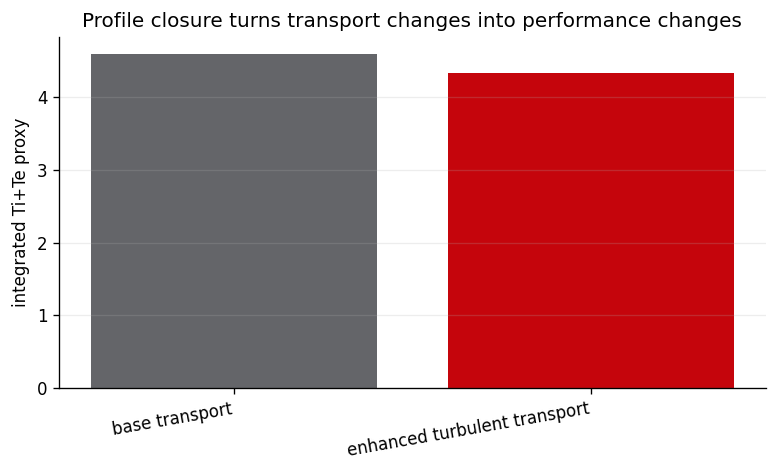

Caption: a design that looks good in field metrics can still lose stored-energy proxy after profile closure.


In [13]:
from sos2026.transport_helpers import profile_closure
profiles = profile_closure()
stored_base = np.trapezoid(profiles["Ti_base"] + profiles["Te"], profiles["r"])
stored_turb = np.trapezoid(profiles["Ti_turbulent"] + profiles["Te"], profiles["r"])
summary = pd.DataFrame({"case": ["base transport", "enhanced turbulent transport"], "stored-energy proxy": [stored_base, stored_turb]})
display(summary)
fig, ax = plt.subplots(figsize=(7.6, 3.8))
ax.bar(summary["case"], summary["stored-energy proxy"], color=["#646569", "#c5050c"])
ax.set_ylabel("integrated Ti+Te proxy")
ax.set_title("Profile closure turns transport changes into performance changes")
ax.grid(axis="y", alpha=0.22)
plt.xticks(rotation=10, ha="right")
plt.show()
print("Caption: a design that looks good in field metrics can still lose stored-energy proxy after profile closure.")

## Output review prompt

Before using this notebook in class, check that the final plot has a clear title, readable axes, and a caption that states what design decision it supports.

## Try this
Change one scalar or one row in the cached data and regenerate the primary plot.

## Expected qualitative answer
The plot should move in a physically interpretable direction, but the cached result remains an educational proxy.

## Research extension
Replace the cached data source with the corresponding real package output after timing and API verification.